# Figure 6: Host-Microbe Interaction, sparceCCA

- PCA of CCA components, with individual components plotted
- Correlation between the host and microbe components
- PCA of microbe-only and host-only components

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import random
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from PIL import Image, ImageDraw, ImageOps

from sklearn.preprocessing import scale
from sklearn.decomposition import PCA

from scipy import stats

## Make Figure Layout

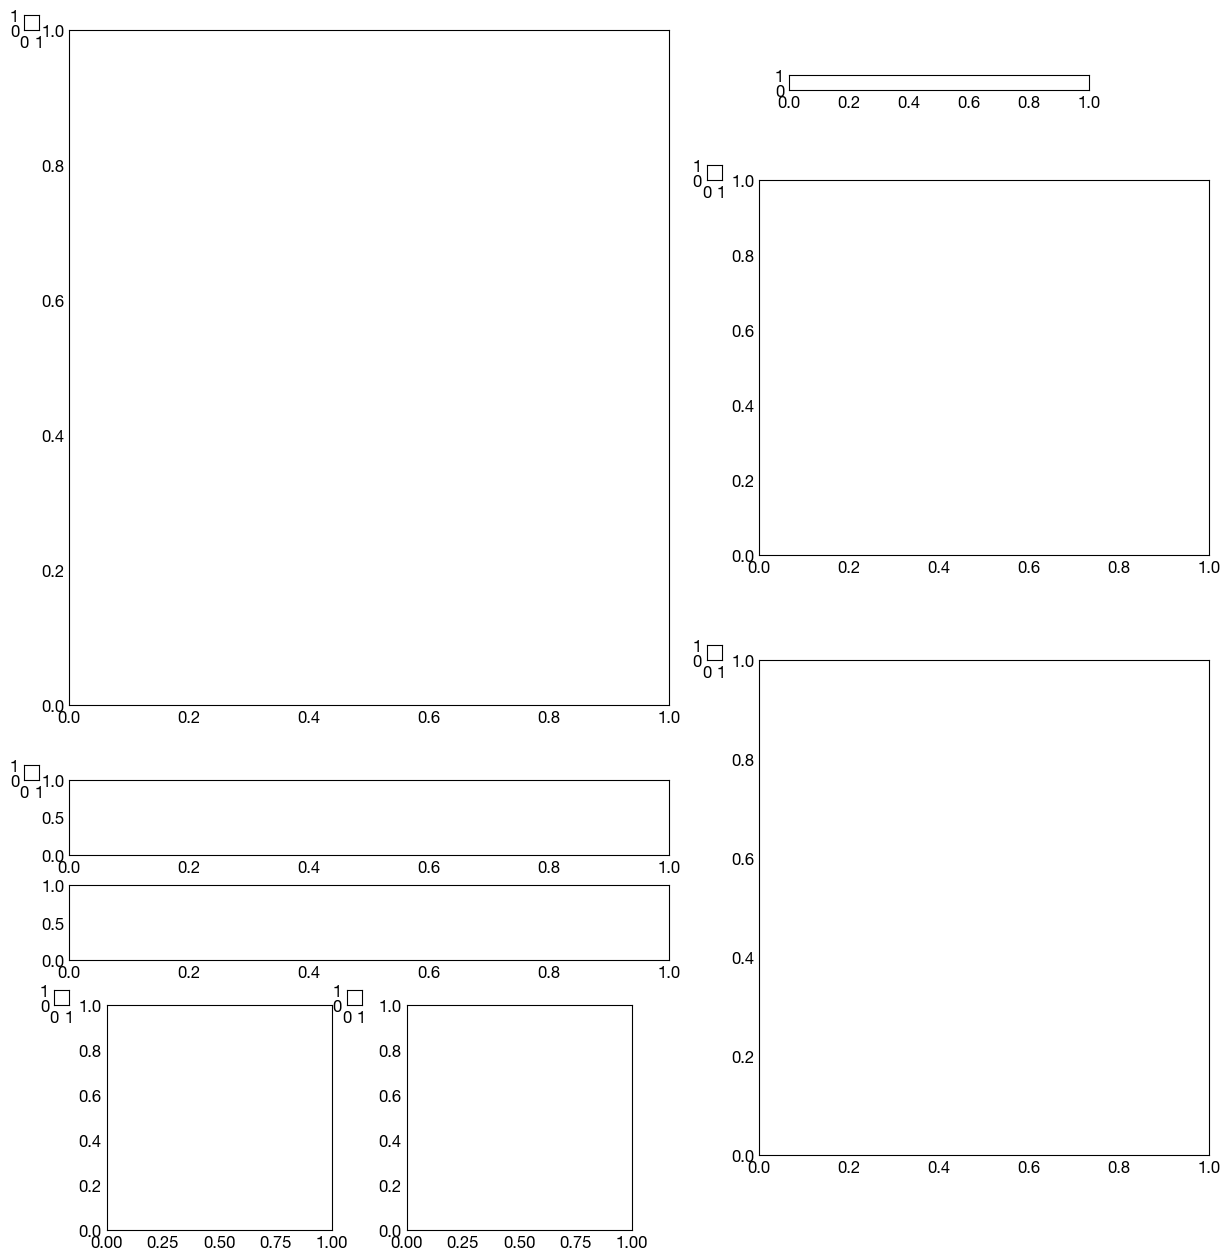

In [28]:
# figure size
WIDTH = 15
HEIGHT = 15

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))


### add the axes

ax1 = fig.add_axes([0.05, 0.55, 0.40, 0.45])
ax2 = fig.add_axes([0.05, 0.45, 0.40, 0.05]) 
ax3 = fig.add_axes([0.05, 0.38, 0.40, 0.05]) 

ax4 = fig.add_axes([0.075, 0.2, 0.15, 0.15]) 
ax5 = fig.add_axes([0.275, 0.2, 0.15, 0.15]) 

ax6 = fig.add_axes([0.51, 0.65, 0.3, 0.25]) 
ax7 = fig.add_axes([0.51, 0.25, 0.3, 0.33])


cst_cbar_ax = fig.add_axes([0.53, 0.96, 0.2, 0.01])

# axes for figure labels
a_ax = fig.add_axes([0.02, 1, 0.01, 0.01])
b_ax = fig.add_axes([0.02, 0.5, 0.01, 0.01])
c_ax = fig.add_axes([0.04, 0.35, 0.01, 0.01])

d_ax = fig.add_axes([0.235, 0.35, 0.01, 0.01])
e_ax = fig.add_axes([0.475, 0.9, 0.01, 0.01])
f_ax = fig.add_axes([0.475, 0.58, 0.01, 0.01])


## Read in data and do the analysis

In [29]:
cst_colors = {
    'I':'#fe0308',
    'II':'#86c61f',
    'III':'#ff7200',
    'IV-A':'#448a73',
    'IV-B':'#221886',
    'IV-C':'#989898',
    'V':'#fae50d'
}

#read in sample metadata
sample_metadata = pd.read_csv('./common/mmtm_metadata.csv')

#concat cst infomation
cst_info = pd.read_csv('./fig6_datasets/mmtm_mt_cst_assignments_06122024_renamed.csv')
sample_metadata = pd.merge(sample_metadata, cst_info, left_on='IGS LABEL', right_on='sampleID', how='outer')

#group the cst assignments
sample_metadata['isCSTIV'] = sample_metadata['CST'].isin(['IV-A', 'IV-B', 'IV-C'])

TARGET_VECTOR = 'X2'

results1 = pd.read_csv('./fig6_datasets/host_mt_gene-microbe_mt_kegg_HOST.csv').rename(columns={'Unnamed: 0':'target'})
results1['target'] = results1['target'].str.replace('.', '-')

results2 = pd.read_csv('./fig6_datasets/host_mt_gene-microbe_mt_kegg_MICROBE.csv').rename(columns={'Unnamed: 0':'target'})
results2['target'] = results2['target'].str.replace('.', '-')

#########
#data1 = pd.read_csv('./fig6_datasets/MMTM_host_featureCounts_0520204_tpms.csv')

ht_counts = pd.read_csv('./fig6_datasets/MMTM_host_featureCounts_0520204_gl.csv').fillna(0)

#rename columns
filt_col = ['Geneid', 'Length']
#filt_col = ['Geneid']
filt_col.extend([c for c in ht_counts.columns if c.startswith('MT_')])
ht_counts = ht_counts[filt_col]
ht_counts = ht_counts.rename(columns=lambda x: x.split('_')[1] if x.startswith('MT_MTM') and x.endswith('_ZYMO') else x)
ht_counts

#filter out samples with few reads
column_sums = ht_counts.iloc[:, 2:].sum()
filtered_columns = column_sums[column_sums >= 5E6].index
ht_counts = ht_counts.loc[:, list(ht_counts.columns[:2]) + list(filtered_columns)]


#correct for gene length
ht_counts = ht_counts[ht_counts['Length'] > 500]
glcorr_data = ht_counts[ht_counts.columns[2:]].div(ht_counts['Length'],axis=0)
ht_counts = pd.concat([ht_counts[ht_counts.columns[0:2]],glcorr_data],axis=1)

#convert to tpm
corr_counts = ht_counts.iloc[:,2:].div(ht_counts.iloc[:,2:].sum()/1E6, axis=1)
ht_counts = pd.concat([ht_counts[ht_counts.columns[0:2]], corr_counts], axis=1)
ht_counts = ht_counts.drop('Length', axis=1)
data1 = ht_counts

#######



data2 = pd.read_csv('./fig6_datasets/taxa_filt_mmtm_mt_virgo2_kegg_tpms_06122024_junk-genes-removed.csv')
cols = ['KEGG']
cols.extend([c for c in data2.columns if c.startswith('MT_MTM')])
data2 = data2[cols]
data2.columns = [c.split('_')[1] if 'MT' in c else c for c in data2.columns]

# filter data so it only contains genes/keggs that were in the results, scale, and merge
data1_targets = results1[results1[TARGET_VECTOR] != 0]['target'].values
data2_targets = results2[results2[TARGET_VECTOR] != 0]['target'].values
data1 = data1[data1['Geneid'].isin(data1_targets)]
data2 = data2[data2['KEGG'].isin(data2_targets)]

data1.iloc[:,1:] = scale(data1.iloc[:,1:], axis=1)
data2.iloc[:,1:] = scale(data2.iloc[:,1:], axis=1)

data1 = data1.set_index('Geneid').T.reset_index().rename(columns={'index':'sample'})
data2 = data2.set_index('KEGG').T.reset_index().rename(columns={'index':'sample'})
all_data = pd.merge(data1, data2, on='sample')

# PCA
pca_emb = PCA(n_components=5)
pca_res = pd.DataFrame(pca_emb.fit_transform(all_data.iloc[:,1:]))
var_exp = pca_emb.explained_variance_ratio_
var_exp = [round(n, 3) for n in var_exp]

pca_res['location'] = pd.Series(all_data['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Cervix/Vagina'].values[0])
pca_res['tp'] = pd.Series(all_data['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Timepoint'].values[0])
pca_res['cst'] = pd.Series(all_data['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['CST'].values[0])

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_87850/2838814451.py:24: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  results1['target'] = results1['target'].str.replace('.', '-')
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_87850/2838814451.py:27: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  results2['target'] = results2['target'].str.replace('.', '-')
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_87850/2838814451.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

## Plot the PCA

In [30]:
sns.scatterplot(data=pca_res, x=0, y=1, ax=ax1, hue='cst', palette=cst_colors, legend=False)
ax1.set_xlabel('PCA-1(' + '{:.1f}'.format(100*var_exp[0]) + '% explained)')
ax1.set_ylabel('PCA-2(' + '{:.1f}'.format(100*var_exp[1]) + '% explained)')

Text(35.56944444444444, 0.5, 'PCA-2(9.0% explained)')

## Plot the genes and keggs in the components

In [31]:
# read in the genes/keggs to annotate
pathway_labels = pd.read_csv('./fig6_datasets/cca_pathway_labels.csv')


In [32]:
def adj_locs(locs, s=0.5, j=0.2):
    adj_loc = []

    for i in range(len(locs)):
        if i == 0:
            adj_loc.append(locs[i])
        else:
            if locs[i] - adj_loc[i-1] <= s:
                adj_loc.append(locs[i] + j)
            else:
                adj_loc.append(locs[i])
    
    return adj_loc

In [33]:
## plotting the host components
ax=ax3
loc = 0

annots = {'locs':[], 'c':[]}

#plot negatives
for i, row in results1[results1[TARGET_VECTOR] < 0][[TARGET_VECTOR, 'target']].iterrows():
    info = pathway_labels[pathway_labels['kegg'] == row['target']]
    if len(info) == 0:
        ax.bar(x=loc, width=0.1, height=row[TARGET_VECTOR], color='gray', zorder=0, alpha=0.3)
    else:
        ax.bar(x=loc, width=0.1, height=row[TARGET_VECTOR], color=info['color'].values[0], zorder=1)
        #ax.plot([loc], [0.05], marker='o', color=info['color'].values[0], markersize=5)
        annots['locs'].append(loc)
        annots['c'].append(info['color'].values[0])
    loc += 0.1

#plot positives
for i, row in results1[results1[TARGET_VECTOR] > 0][[TARGET_VECTOR, 'target']].iterrows():
    info = pathway_labels[pathway_labels['kegg'] == row['target']]
    if len(info) == 0:
        ax.bar(x=loc, width=0.1, height=row[TARGET_VECTOR], color='gray', alpha=0.3)
    else:
        ax.bar(x=loc, width=0.1, height=row[TARGET_VECTOR], color=info['color'].values[0])
        annots['locs'].append(loc)
        annots['c'].append(info['color'].values[0])
    loc += 0.1


annots['locs'] = adj_locs(annots['locs'])
y_pos = max(ax.get_ylim())*0.75
for l, c in dict(zip(annots['locs'], annots['c'])).items():
    ax.plot([l], [y_pos], marker='o', color=c, markersize=8)

#ax.axhline(y=0, color='black')
ax.set_yticklabels('')
ax.set_xticklabels('')
ax.set_ylabel('Host\nCanonical Weights', fontsize='8')


## plotting the microbe components
ax=ax2
loc = 0

annots = {'locs':[], 'c':[]}

#plot negatives
for i, row in results2[results2[TARGET_VECTOR] < 0][[TARGET_VECTOR, 'target']].iterrows():
    info = pathway_labels[pathway_labels['kegg'] == row['target']]
    if len(info) == 0:
        ax.bar(x=loc, width=0.1, height=row[TARGET_VECTOR], color='gray', alpha=0.3)
    else:
        ax.bar(x=loc, width=0.5, height=row[TARGET_VECTOR], color=info['color'].values[0])
        #ax.plot([loc], [0.1], marker='o', color=info['color'].values[0], markersize=5)
        annots['locs'].append(loc)
        annots['c'].append(info['color'].values[0])
    loc += 0.1

#plot positives
for i, row in results2[results2[TARGET_VECTOR] > 0][[TARGET_VECTOR, 'target']].iterrows():
    info = pathway_labels[pathway_labels['kegg'] == row['target']]
    if len(info) == 0:
        ax.bar(x=loc, width=0.1, height=row[TARGET_VECTOR], color='gray', alpha=0.3)
    else:
        ax.bar(x=loc, width=0.5, height=row[TARGET_VECTOR], color=info['color'].values)
        annots['locs'].append(loc)
        annots['c'].append(info['color'].values[0])
    loc += 0.1

annots['locs'] = adj_locs(annots['locs'], s=1, j=1)
y_pos = max(ax.get_ylim())*0.75
for l, c in dict(zip(annots['locs'], annots['c'])).items():
    ax.plot([l], [y_pos], marker='o', color=c, markersize=8)

#ax.axhline(y=0, color='black')
ax.set_yticklabels('')
ax.set_xticklabels('')
ax.set_ylabel('Microbial\nCanonical Weights', fontsize='8')

Text(35.56944444444444, 0.5, 'Microbial\nCanonical Weights')

## PCA for Microbe and Host individually

In [34]:
# host only
pca_emb = PCA(n_components=5)
pca_res = pd.DataFrame(pca_emb.fit_transform(data1.iloc[:,1:]))
var_exp = pca_emb.explained_variance_ratio_
var_exp = [round(n, 3) for n in var_exp]

pca_res['location'] = pd.Series(data1['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Cervix/Vagina'].values[0])
pca_res['tp'] = pd.Series(data1['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Timepoint'].values[0])
pca_res['cst'] = pd.Series(data1['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['CST'].values[0])


#plot
ax = ax4

sns.scatterplot(data=pca_res, x=0, y=1, ax=ax, hue='cst', palette=cst_colors, legend=False)
ax.set_xlabel('PCA-1(' + '{:.1f}'.format(100*var_exp[0]) + '% explained)')
ax.set_ylabel('PCA-2(' + '{:.1f}'.format(100*var_exp[1]) + '% explained)')

ax.set_title('Host Component')

# microbe only
pca_emb = PCA(n_components=5)
pca_res = pd.DataFrame(pca_emb.fit_transform(data2.iloc[:,1:]))
var_exp = pca_emb.explained_variance_ratio_
var_exp = [round(n, 3) for n in var_exp]

pca_res['location'] = pd.Series(data2['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Cervix/Vagina'].values[0])
pca_res['tp'] = pd.Series(data2['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Timepoint'].values[0])
pca_res['cst'] = pd.Series(data2['sample']).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['CST'].values[0])


#plot
ax = ax5

sns.scatterplot(data=pca_res, x=0, y=1, ax=ax, hue='cst', palette=cst_colors, legend=False)
ax.set_xlabel('PCA-1(' + '{:.1f}'.format(100*var_exp[0]) + '% explained)')
ax.set_ylabel('PCA-2(' + '{:.1f}'.format(100*var_exp[1]) + '% explained)')

ax.set_title('Microbial Component')

Text(0.5, 1.0, 'Microbial Component')

## Correlation between components

In [35]:
#read in the full datasets
data1 = pd.read_csv('./fig6_datasets/MMTM_host_featureCounts_0520204_tpms.csv')

data2 = pd.read_csv('./fig6_datasets/taxa_filt_mmtm_mt_virgo2_kegg_tpms_06122024_junk-genes-removed.csv')

cols = ['KEGG']
cols.extend([c for c in data2.columns if c.startswith('MT_MTM')])
data2 = data2[cols]
data2.columns = [c.split('_')[1] if 'MT' in c else c for c in data2.columns]

data1_targets = results1[results1['X2'] != 0]['target'].values
data2_targets = results2[results2['X2'] != 0]['target'].values
data1 = data1[data1['Geneid'].isin(data1_targets)]
data2 = data2[data2['KEGG'].isin(data2_targets)]


#pull out results that have a non-zero canonical weight
results1 = results1[results1['X2'] != 0][['target', 'X2']]
results2 = results2[results2['X2'] != 0][['target', 'X2']]


#sort the coefficients and data so they are in the same order and can be multiplied 
results1 = results1.sort_values(by='target')
data1 = data1.sort_values(by='Geneid')

results2 = results2.sort_values(by='target')
data2 = data2.sort_values(by='KEGG')

#scale and multiply
scaled1 = pd.DataFrame(scale(data1.iloc[:,1:], axis= 1))
scaled2 = pd.DataFrame(scale(data2.iloc[:,1:], axis = 1))

weights1 = np.dot(results1['X2'], scaled1)
weights2 = np.dot(results2['X2'], scaled2)

to_plot = pd.DataFrame({'1':list(weights1), '2':list(weights2)})


ax = ax6
sns.scatterplot(data=to_plot, x='1', y='2', ax=ax, color='black', edgecolor='black')

r2 = stats.pearsonr(to_plot['1'].values, to_plot['2'].values).statistic
print(r2)

ax.text(x=7.5, y=-25, s=r'$r^2$ = ' + '{:.3f}'.format(r2))


ax.set_xlabel('Human Genes\nCanonical Component')
ax.set_ylabel('Microbial KEGG\nCanonical Component')
ax.set_title('Host Gene and Microbial KEGG Expression\nCanonical Components Correlation')

0.853834779230931


Text(0.5, 1.0, 'Host Gene and Microbial KEGG Expression\nCanonical Components Correlation')

## Add the pathay figure

In [36]:
path_fig = Image.open('./fig6_datasets/mmtm_fig6_1.png')
ax7.imshow(np.array(path_fig))
ax7.set_axis_off()

## Add CST Colorbar Legend

In [37]:
my_cst_cmap = matplotlib.colors.ListedColormap(['#fe0308', '#ff7200','#448a73','#221886', '#989898', '#fae50d'])
pt_cbarCST = matplotlib.colorbar.ColorbarBase(cst_cbar_ax, cmap=my_cst_cmap, orientation = 'horizontal',ticklocation='top',
                                              ticks=[0.08,0.24,0.40,0.57,0.755,0.90])
pt_cbarCST.ax.set_xticklabels(['I', 'III', 'IV-A', 'IV-B', 'IV-C', 'V'], rotation=45)
cst_cbar_ax.set_ylim(1,0)
cst_cbar_ax.text(x=-0.15,y=0.8,s=r"CST")

Text(-0.15, 0.8, 'CST')

## Add Figure Labels

In [38]:
labels = ['A', 'B', 'C', 'D', 'E', 'F']
for ax in [a_ax, b_ax, c_ax, d_ax, e_ax, f_ax]:
    ax.text(x=0,y=0,s=labels.pop(0),fontsize=24, weight='bold')
    ax.set_axis_off()

## Save Figure

In [ ]:
fig.savefig('fig6_V2.pdf', format='pdf', bbox_inches='tight')

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
